# Perturbation score — tonsil

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import plotly.graph_objects as go
import plotly.io as pio


list of TFs enriched in episodic

In [2]:

all_path = "/work/nvme/bhdw/asachan/data_files/firefate/bcell/celloracle_PS_files/Tonsil_all_scores.csv"

all = pd.read_csv(all_path)


In [3]:
all.shape

(107, 16)

In [4]:
# All TFs from dictys hits based on curve shape analysis
dictys_tfs = [
    "BACH2", "BATF3", "BHLHE22", "BHLHE40", "BHLHE41", "E2F4", "E2F6",
    "EGR1", "EGR2", "EGR3", "ETV5", "FOS", "FOSL2", "GLI1", "HES1",
    "HNF1B", "HOMEZ", "HSF5", "IRF8", "KLF9", "LEF1", "MEF2B", "MYC",
    "MYPOP", "NFATC4", "NFIL3", "NR4A1", "PATZ1", "PBX4", "POU2F3",
    "PPARA", "PRDM1", "REL", "RUNX2", "SNAI3", "SOX2", "SOX5", "SREBF1",
    "ST18", "TBX21", "TCF7L2", "TFAP4", "TGIF1", "THRB", "TP73", "VDR",
    "XBP1", "YBX1", "ZBTB17", "ZBTB48", "ZFP3", "ZFP14", "ZNF16",
    "ZNF35", "ZNF202", "ZNF222", "ZNF385D", "ZNF418", "ZNF419", "ZNF441",
    "ZNF443", "ZNF540", "ZNF563", "ZNF566", "ZNF580", "ZNF595", "ZNF605",
    "ZNF653", "ZNF695", "ZNF764", "ZNF793", "ZNF823"
]

In [5]:
# FocalFire temporal TFs: union of the PB and GC TFs called enriched by the Fig3_2
# episodic-enrichment dotplots (analysis/Fig3_2_episodic_enrichment.ipynb, fixed
# enrichment tables, p <= 0.05). PB: IKZF3 BHLHE40 TFEC REL MEF2C MAX STAT3 CREB3L2
# MEF2A RUNX3; GC: CREB3L2 NFATC2 IRF1 IKZF3 RUNX3 CDC5L MAX MYC MEF2C STAT6 TCF12.
firefate_dynamic_tfs = ["IKZF3", "BHLHE40", "TFEC", "REL", "MEF2C", "MAX", "STAT3", "CREB3L2",
"MEF2A", "RUNX3", "NFATC2", "IRF1", "CDC5L", "MYC", "STAT6", "TCF12"]

TFs_dynamic_scores = all[all["goi"].isin(firefate_dynamic_tfs)]
print(TFs_dynamic_scores.shape)
TFs_dictys_scores = all[all["goi"].isin(dictys_tfs)]
print(TFs_dictys_scores.shape)

(9, 16)
(19, 16)


In [6]:
# Filter dataframe
subset_df = all[~all["goi"].isin(firefate_dynamic_tfs)]

firefate_dynamic_df = all[all["goi"].isin(firefate_dynamic_tfs)]

# Optional: check result
print(subset_df.shape)
print(firefate_dynamic_df.shape)

(98, 16)
(9, 16)


In [7]:
allexceptdynamic_df = all[~all["goi"].isin(TFs_dynamic_scores['goi'])]
print(allexceptdynamic_df.shape)

u_stat, p_value = stats.mannwhitneyu(
    TFs_dynamic_scores["overall_total"],
    allexceptdynamic_df["overall_total"],
    #alternative="two-sided"
    alternative="greater"
)

print("Mann–Whitney U p-value for dynamic:", p_value)

(98, 16)
Mann–Whitney U p-value for dynamic: 0.0017287652558627248


In [8]:
# --- FIREFate dynamic vs. random background, and vs. Dictys ---

ff_vals = all[all["goi"].isin(firefate_dynamic_tfs)]["overall_total"].values

# Random / background: all TFs except FIREFate dynamic
other_vals = all[~all["goi"].isin(firefate_dynamic_tfs)]["overall_total"].values

# Dictys hits, excluding the overlap with FIREFate dynamic (BHLHE40, MYC, REL)
dictys_only_vals = all[
    all["goi"].isin(dictys_tfs) & ~all["goi"].isin(firefate_dynamic_tfs)
]["overall_total"].values

def cliffs_delta(x, y):
    """Cliff's delta P(x > y) - P(x < y), from the Mann-Whitney U of x."""
    u, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 2 * u / (len(x) * len(y)) - 1

u_stat, p_other = stats.mannwhitneyu(ff_vals, other_vals, alternative="greater")
delta_other = cliffs_delta(ff_vals, other_vals)
print(f"FIREFate dynamic (n={len(ff_vals)}) vs all other TFs (n={len(other_vals)}): "
      f"U={u_stat:.1f}, p={p_other:.3e}, Cliff's delta={delta_other:.3f}")

u_stat, p_dictys = stats.mannwhitneyu(ff_vals, dictys_only_vals, alternative="greater")
delta_dictys = cliffs_delta(ff_vals, dictys_only_vals)
print(f"FIREFate dynamic (n={len(ff_vals)}) vs Dictys TFs (n={len(dictys_only_vals)}): "
      f"U={u_stat:.1f}, p={p_dictys:.3e}, Cliff's delta={delta_dictys:.3f}")

FIREFate dynamic (n=9) vs all other TFs (n=98): U=702.0, p=1.729e-03, Cliff's delta=0.592
FIREFate dynamic (n=9) vs Dictys TFs (n=17): U=103.0, p=8.056e-02, Cliff's delta=0.346


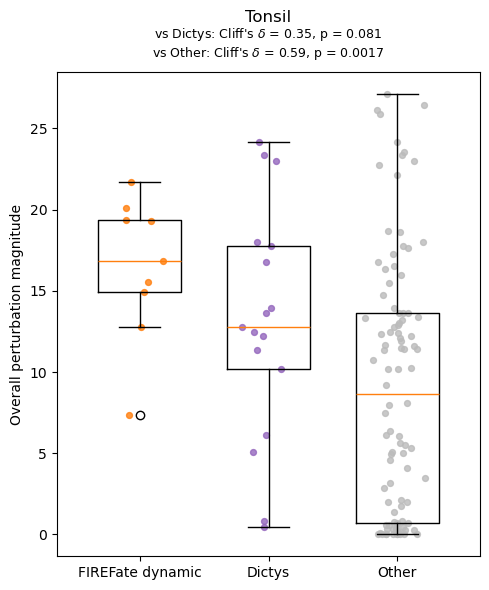

In [9]:
fig = plt.figure(figsize=(5,6))

positions = [1, 1.28, 1.56]
data = [ff_vals, dictys_only_vals, other_vals]
labels = ["FIREFate dynamic", "Dictys", "Other"]

# boxplot
plt.boxplot(data, positions=positions, widths=0.18)

colors = ["tab:orange", "tab:purple", "#bbbbbb"]

# overlay individual TF points
for i, y in enumerate(data):
    x = np.random.normal(positions[i], 0.025, size=len(y))
    plt.scatter(x, y, alpha=0.8, color=colors[i], s=18)

plt.xticks(positions, labels)
plt.xlim(positions[0] - 0.18, positions[-1] + 0.18)
plt.ylabel("Overall perturbation magnitude")

# Cliff's delta (FIREFate dynamic vs each comparison group), with one-sided MWU p
ax = plt.gca()
ax.text(0.5, 1.02,
        f"vs Dictys: Cliff's $\\delta$ = {delta_dictys:.2f}, p = {p_dictys:.2g}\n"
        f"vs Other: Cliff's $\\delta$ = {delta_other:.2f}, p = {p_other:.2g}",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=9)
ax.set_title("Tonsil", pad=36)  # above the Cliff's delta annotation

plt.tight_layout()
# save the plot
fig.savefig(
    os.path.join("/projects/bhdw/asachan/papers/firefate/figures",
                 "dictys_benchmark_ff_dynamic_tonsil.pdf"),
    bbox_inches="tight"
)
plt.show()

In [10]:
# --- FIREFate state-specific vs. random background, and vs. Dictys ---
# State-specific TFs from the PB/GC LF enrichment (Fig 2B)
firefate_state_tfs = ["PRDM1", "BACH2", "XBP1", "IRF4", "RUNX2", "CREB3L2",
"PAX5", "TCF12", "TFEC", "BATF", "PBX3", "ARID5B"]

state_vals = all[all["goi"].isin(firefate_state_tfs)]["overall_total"].values

# Random / background: all TFs except FIREFate state-specific
other_vals_state = all[~all["goi"].isin(firefate_state_tfs)]["overall_total"].values

# Dictys hits, excluding the overlap with FIREFate state-specific (BACH2, PRDM1, RUNX2, XBP1)
dictys_only_vals_state = all[
    all["goi"].isin(dictys_tfs) & ~all["goi"].isin(firefate_state_tfs)
]["overall_total"].values

u_stat, p_other_state = stats.mannwhitneyu(state_vals, other_vals_state, alternative="greater")
delta_other_state = cliffs_delta(state_vals, other_vals_state)
print(f"FIREFate state-specific (n={len(state_vals)}) vs all other TFs (n={len(other_vals_state)}): "
      f"U={u_stat:.1f}, p={p_other_state:.3e}, Cliff's delta={delta_other_state:.3f}")

u_stat, p_dictys_state = stats.mannwhitneyu(state_vals, dictys_only_vals_state, alternative="greater")
delta_dictys_state = cliffs_delta(state_vals, dictys_only_vals_state)
print(f"FIREFate state-specific (n={len(state_vals)}) vs Dictys TFs (n={len(dictys_only_vals_state)}): "
      f"U={u_stat:.1f}, p={p_dictys_state:.3e}, Cliff's delta={delta_dictys_state:.3f}")


FIREFate state-specific (n=12) vs all other TFs (n=95): U=830.0, p=5.205e-03, Cliff's delta=0.456
FIREFate state-specific (n=12) vs Dictys TFs (n=15): U=102.0, p=2.874e-01, Cliff's delta=0.133


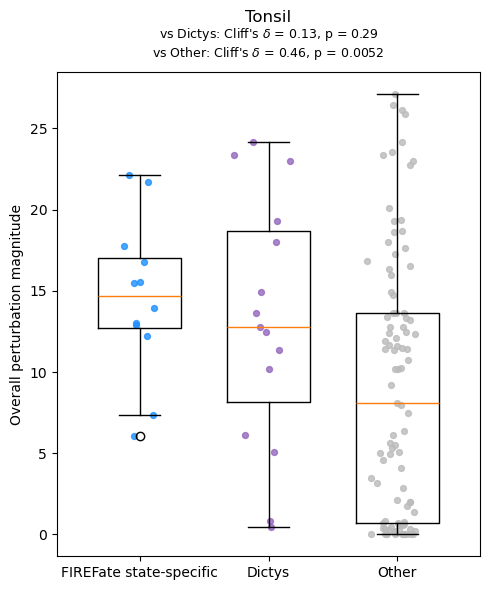

In [11]:
fig = plt.figure(figsize=(5,6))

positions = [1, 1.28, 1.56]
data = [state_vals, dictys_only_vals_state, other_vals_state]
labels = ["FIREFate state-specific", "Dictys", "Other"]

# boxplot
plt.boxplot(data, positions=positions, widths=0.18)

colors = ["dodgerblue", "tab:purple", "#bbbbbb"]

# overlay individual TF points
for i, y in enumerate(data):
    x = np.random.normal(positions[i], 0.025, size=len(y))
    plt.scatter(x, y, alpha=0.8, color=colors[i], s=18)

plt.xticks(positions, labels)
plt.xlim(positions[0] - 0.18, positions[-1] + 0.18)
plt.ylabel("Overall perturbation magnitude")

# Cliff's delta (FIREFate state-specific vs each comparison group), with one-sided MWU p
ax = plt.gca()
ax.text(0.5, 1.02,
        f"vs Dictys: Cliff's $\\delta$ = {delta_dictys_state:.2f}, p = {p_dictys_state:.2g}\n"
        f"vs Other: Cliff's $\\delta$ = {delta_other_state:.2f}, p = {p_other_state:.2g}",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=9)
ax.set_title("Tonsil", pad=36)  # above the Cliff's delta annotation

plt.tight_layout()
# save the plot
fig.savefig(
    os.path.join("/projects/bhdw/asachan/papers/firefate/figures",
                 "dictys_benchmark_ff_state_tonsil.pdf"),
    bbox_inches="tight"
)
plt.show()
